In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics
import os

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import  RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("Location2.csv")
df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,14.5,91,12.4,6.37,9.58,68,72,9.9,0.2574
1,2017-01-02 01:00:00,14.5,92,12.7,6.46,9.23,68,72,9.5,0.2535
2,2017-01-02 02:00:00,14.7,92,12.7,6.18,9.27,67,74,9.4,0.2497
3,2017-01-02 03:00:00,14.7,92,12.8,5.91,9.08,62,69,9.1,0.2458
4,2017-01-02 04:00:00,14.8,92,12.9,5.88,8.72,58,65,8.7,0.2419


In [ ]:
df = pd.read_csv(r"C:\Users\M.Sufyan\OneDrive\Documents\personal\research work\Train data\Location2.csv")
df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,14.5,91,12.4,6.37,9.58,68,72,9.9,0.2574
1,2017-01-02 01:00:00,14.5,92,12.7,6.46,9.23,68,72,9.5,0.2535
2,2017-01-02 02:00:00,14.7,92,12.7,6.18,9.27,67,74,9.4,0.2497
3,2017-01-02 03:00:00,14.7,92,12.8,5.91,9.08,62,69,9.1,0.2458
4,2017-01-02 04:00:00,14.8,92,12.9,5.88,8.72,58,65,8.7,0.2419


In [4]:
unique_ = df['Power'].unique()
unique_

array([0.2574, 0.2535, 0.2497, ..., 0.6083, 0.3287, 0.4086])

In [5]:
df.columns

Index(['Time', 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
       'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
       'winddirection_100m', 'windgusts_10m', 'Power'],
      dtype='object')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df= df.drop_duplicates()
print("DataFrame after dropping duplicates:")
print(df)

DataFrame after dropping duplicates:
                      Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0      2017-01-02 00:00:00            14.5                   91         12.4   
1      2017-01-02 01:00:00            14.5                   92         12.7   
2      2017-01-02 02:00:00            14.7                   92         12.7   
3      2017-01-02 03:00:00            14.7                   92         12.8   
4      2017-01-02 04:00:00            14.8                   92         12.9   
...                    ...             ...                  ...          ...   
43795  2021-12-31 19:00:00           -17.9                   72        -24.2   
43796  2021-12-31 20:00:00           -18.4                   72        -24.7   
43797  2021-12-31 21:00:00           -18.5                   71        -25.1   
43798  2021-12-31 22:00:00           -18.7                   71        -25.1   
43799  2021-12-31 23:00:00           -18.3                   71        -24.9   

  

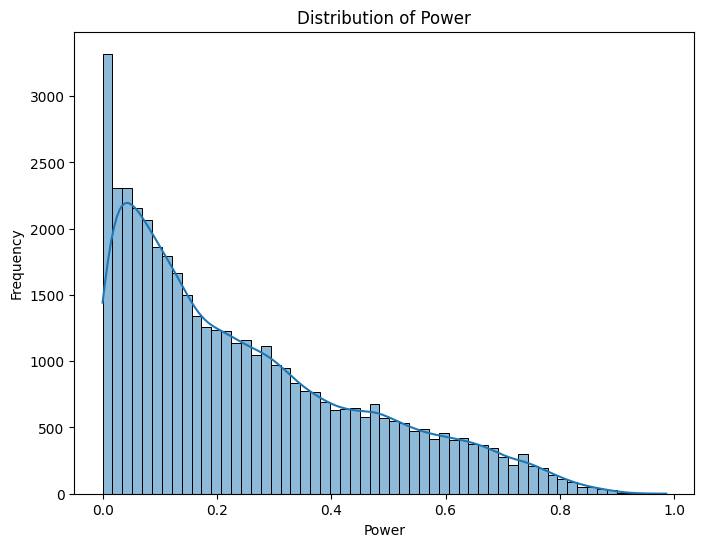

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Power'], kde=True)
plt.title('Distribution of Power')
plt.xlabel('Power')
plt.ylabel('Frequency')
plt.show()

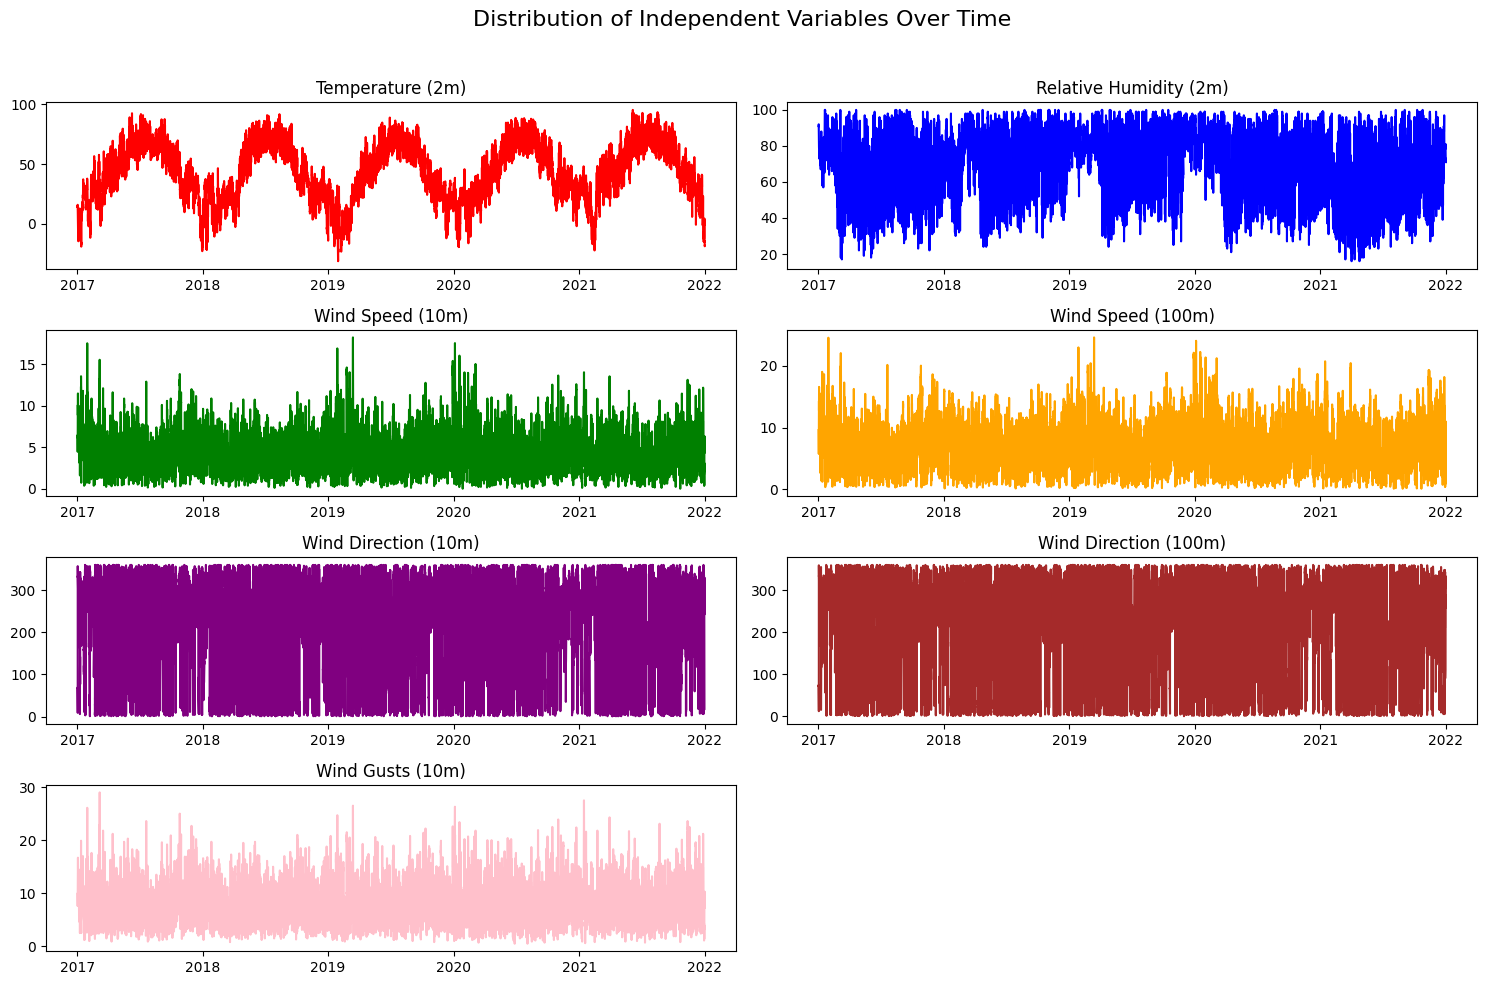

In [9]:
df['Time'] = pd.to_datetime(df['Time'])

# Create the figure and subplots
fig, axs = plt.subplots(4, 2, figsize=(15, 10))
fig.suptitle('Distribution of Independent Variables Over Time', fontsize=16)

# Plot each variable
axs[0, 0].plot(df['Time'], df['temperature_2m'], color='red')
axs[0, 0].set_title('Temperature (2m)')
axs[0, 1].plot(df['Time'], df['relativehumidity_2m'], color='blue')
axs[0, 1].set_title('Relative Humidity (2m)')

axs[1, 0].plot(df['Time'], df['windspeed_10m'], color='green')
axs[1, 0].set_title('Wind Speed (10m)')
axs[1, 1].plot(df['Time'], df['windspeed_100m'], color='orange')
axs[1, 1].set_title('Wind Speed (100m)')

axs[2, 0].plot(df['Time'], df['winddirection_10m'], color='purple')
axs[2, 0].set_title('Wind Direction (10m)')
axs[2, 1].plot(df['Time'], df['winddirection_100m'], color='brown')
axs[2, 1].set_title('Wind Direction (100m)')

axs[3, 0].plot(df['Time'], df['windgusts_10m'], color='pink')
axs[3, 0].set_title('Wind Gusts (10m)')

# Hide the last empty subplot
axs[3, 1].axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


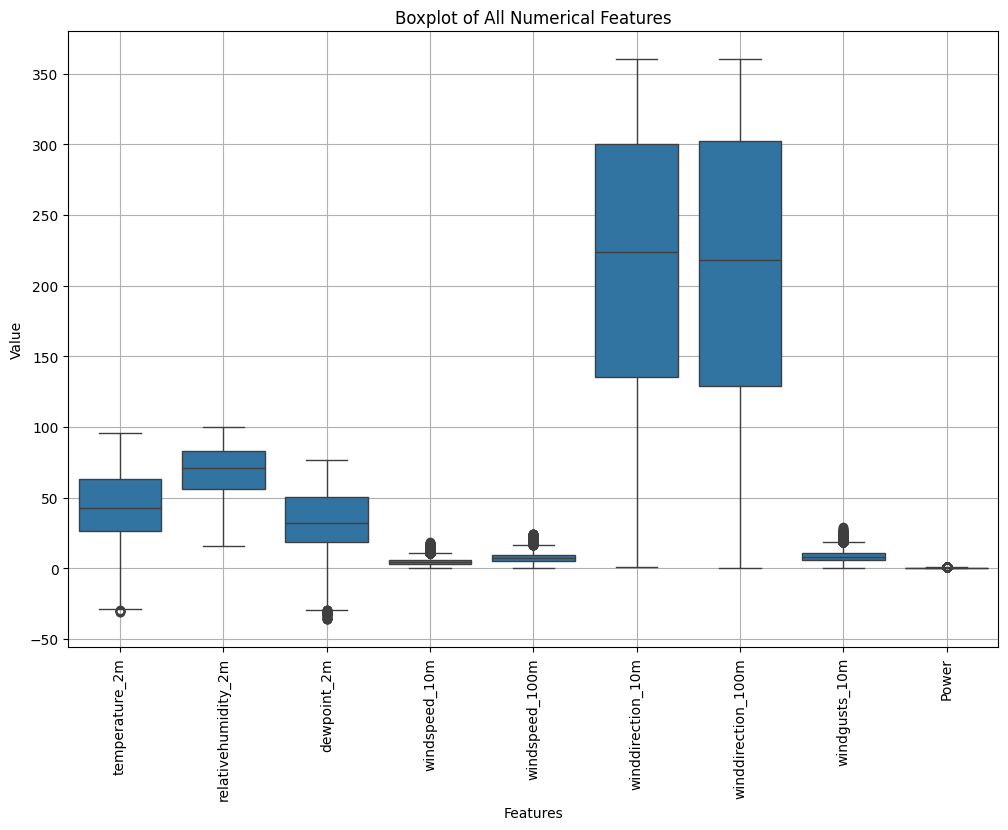

In [10]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Melt the dataframe to long format suitable for seaborn boxplot
df_melted = pd.melt(df[numerical_columns])

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.title('Boxplot of All Numerical Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(True)
plt.show()

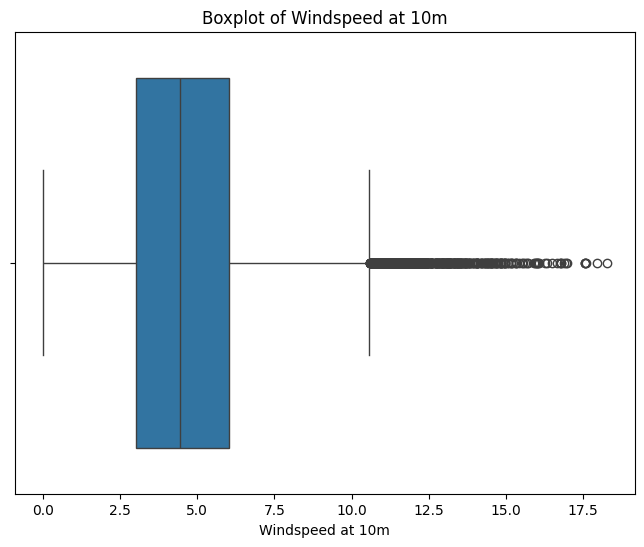

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_10m', data=df)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 10m')
plt.show()

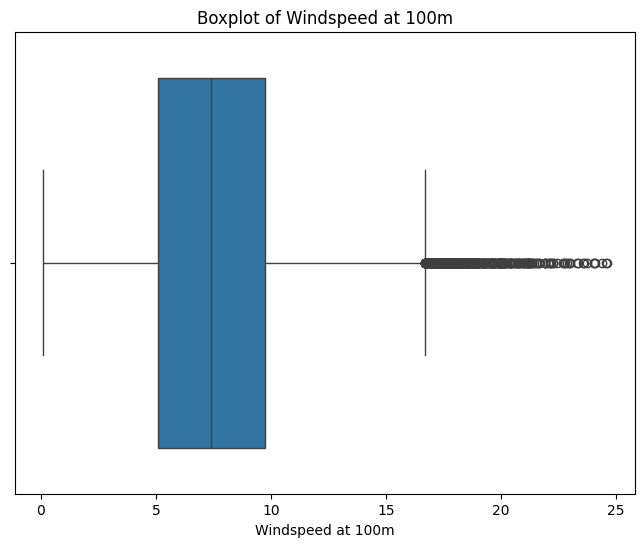

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=df)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [13]:
from scipy import stats
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(numeric_df))

data_cleaned = df[(z_scores < 3).all(axis=1)]

In [14]:
print("Original DataFrame shape:", df.shape)
print("DataFrame shape after removing outliers:", data_cleaned.shape)

Original DataFrame shape: (43800, 10)
DataFrame shape after removing outliers: (43213, 10)


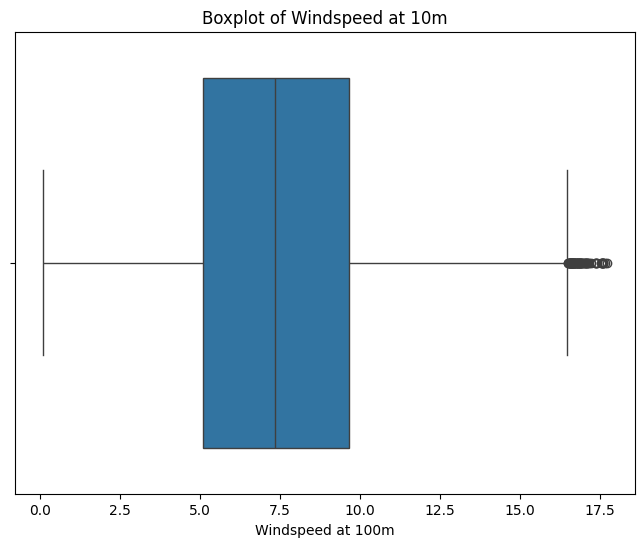

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 100m')
plt.show()

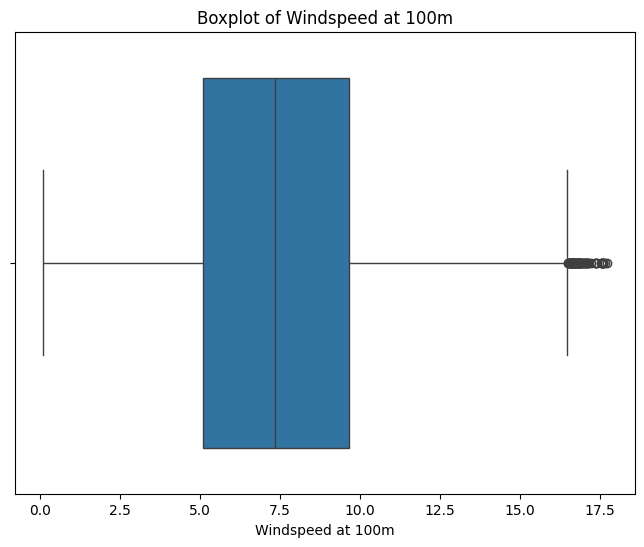

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [17]:
categorical_columns = data_cleaned.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index([], dtype='object')

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming df is your DataFrame
le = LabelEncoder()

# Encode the necessary columns
data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
data_cleaned['relativehumidity_2m'] = le.fit_transform(data_cleaned['relativehumidity_2m'])
data_cleaned['dewpoint_2m'] = le.fit_transform(data_cleaned['dewpoint_2m'])
data_cleaned['windspeed_10m'] = le.fit_transform(data_cleaned['windspeed_10m'])
data_cleaned['windspeed_100m'] = le.fit_transform(data_cleaned['windspeed_100m'])
data_cleaned['winddirection_10m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['winddirection_100m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['windgusts_10m'] = le.fit_transform(data_cleaned['windgusts_10m'])
data_cleaned['Power'] = le.fit_transform(data_cleaned['Power'])


/tmp/ipython-input-3802273176.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
/tmp/ipython-input-3802273176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
/tmp/ipython-input-3802273176.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [19]:
X=data_cleaned.drop(columns='Power')
X=data_cleaned.drop(columns='Time')
X

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,375,73,427,539,858,67,67,94,2570
1,375,74,430,548,823,67,67,90,2533
2,377,74,430,520,827,66,66,89,2495
3,377,74,431,493,808,61,61,86,2456
4,378,74,432,490,772,57,57,82,2417
...,...,...,...,...,...,...,...,...,...
43795,53,54,61,518,962,316,316,91,2528
43796,48,54,56,489,926,312,312,98,2545
43797,47,53,52,532,982,311,311,94,2565
43798,45,53,52,446,863,305,305,94,2585


In [20]:
y = np.asarray(data_cleaned['Power'])

In [21]:
# Remove outliers in 'Power' target using IQR
Q1 = data_cleaned['Power'].quantile(0.25)
Q3 = data_cleaned['Power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned1 = data_cleaned[(data_cleaned['Power'] > lower_bound) & (data_cleaned['Power'] < upper_bound)]

In [22]:
from sklearn.svm import SVR

I applied different splits like 40:60, 30:70, and 20:80 — just changed the test_size value and ran the cell again.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Scale X & y
scalerX = StandardScaler()
scalerY = StandardScaler()

X_train_scaled = scalerX.fit_transform(X_train)
X_test_scaled = scalerX.transform(X_test)

y_train_scaled = scalerY.fit_transform(y_train.reshape(-1,1)).ravel()

# SVR model
svr = SVR(kernel='rbf', C=100, gamma='scale')
svr.fit(X_train_scaled, y_train_scaled)

# Predict
y_pred_scaled = svr.predict(X_test_scaled)
y_pred = scalerY.inverse_transform(y_pred_scaled.reshape(-1,1))

# Metrics
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.9972192974107266
MAE: 90.4444613396788
RMSE: 104.72146401935409


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [ ]:
scalerX = StandardScaler()
scalerY = StandardScaler()

# Scale X
X_train_scaled = scalerX.fit_transform(X_train)
X_test_scaled = scalerX.transform(X_test)

# Scale Y (important!)
y_train_scaled = scalerY.fit_transform(y_train.reshape(-1,1)).ravel()

In [ ]:
svr_model2 = SVR(kernel='linear')  # You can try different kernels: 'linear', 'poly', 'rbf'
svr_model2.fit(X_train_scaled, y_train)

SVR(kernel='linear')

In [ ]:
y_pred_scaled = svr_model2.predict(X_test_scaled)


In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'R-squared: {r2}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

R-squared: 0.9972192974107266
Mean Absolute Error (MAE): 90.4444613396788
Mean Squared Error (MSE): 10966.585026356872
Root Mean Squared Error (RMSE): 104.72146401935409


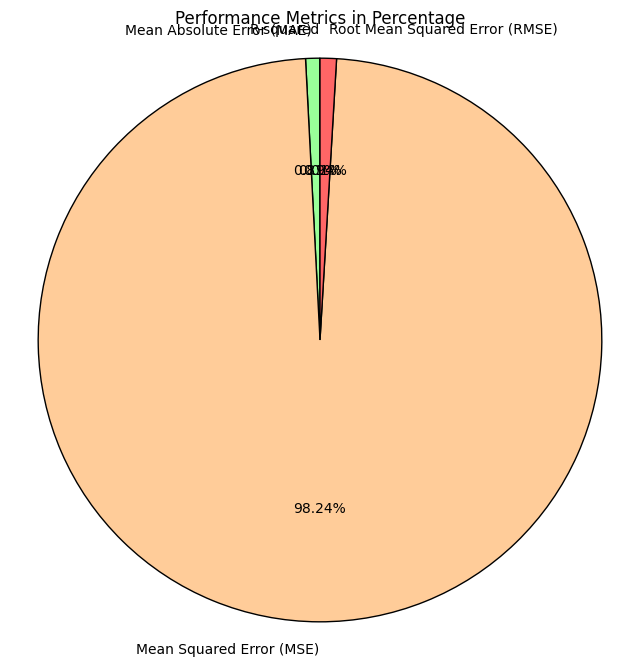

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Assuming you have the predicted and actual values
# y_test = actual values, y_pred = predicted values

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Create the performance metrics list
metrics = [r2, mae, mse, rmse]
metrics_names = ['R-squared', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)']

# Normalize the values to get the percentage for the pie chart
total = sum(metrics)
percentages = [metric / total * 100 for metric in metrics]

# Set color palette for the pie chart
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff6666']

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=metrics_names, autopct='%1.2f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Performance Metrics in Percentage')

# Display the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()

/tmp/ipython-input-727162896.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')


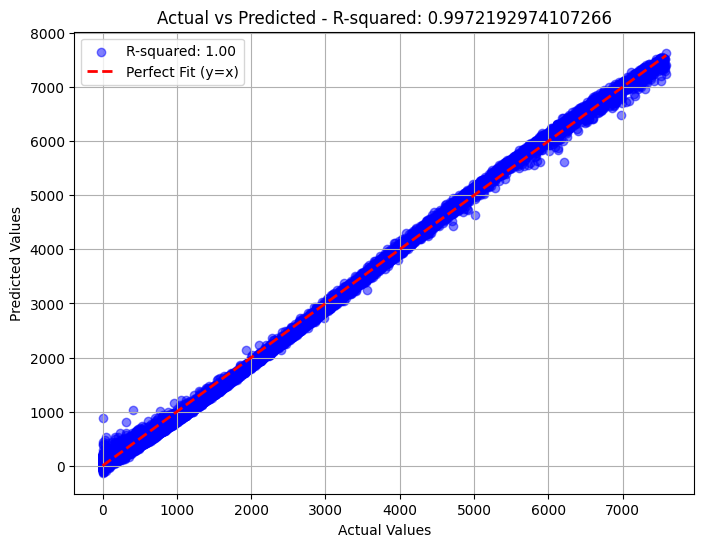

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label=f'R-squared: {r2:.2f}')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')
plt.title(f'Actual vs Predicted - R-squared: {r2}')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reg_model_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})
reg_model_diff

ValueError: Per-column arrays must each be 1-dimensional

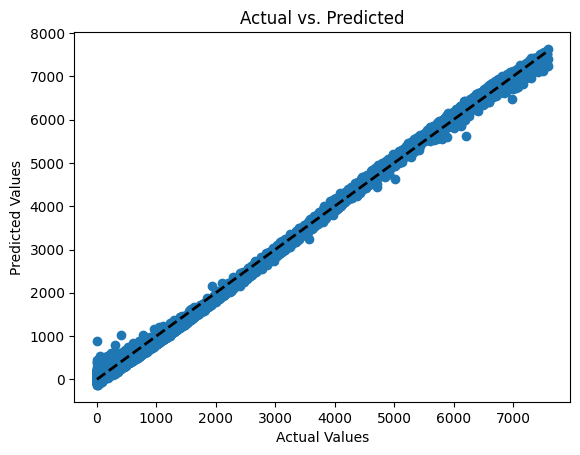

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

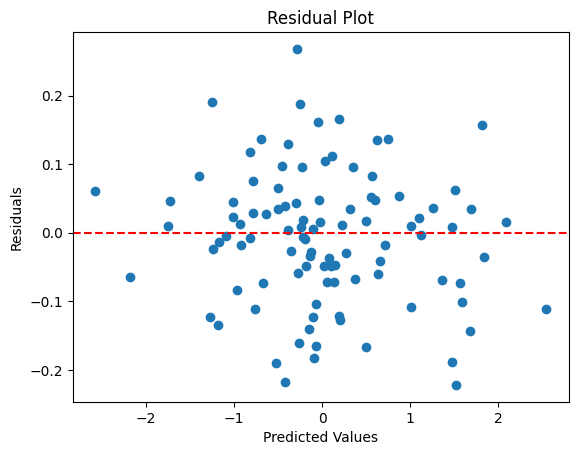

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated true values and predictions
y_true = np.random.normal(0, 1, 100)
y_pred = y_true + np.random.normal(0, 0.1, 100)  # predicted values with some noise

residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

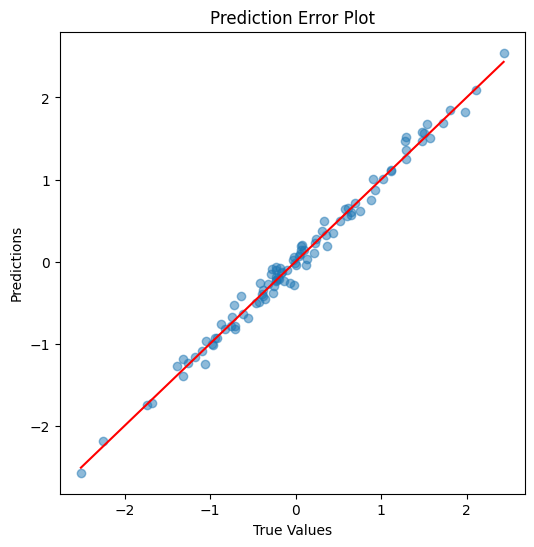

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red')  # Diagonal line
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Prediction Error Plot')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\M.Sufyan\\OneDrive\\Documents\\images ML paper/acc linear 2.png'

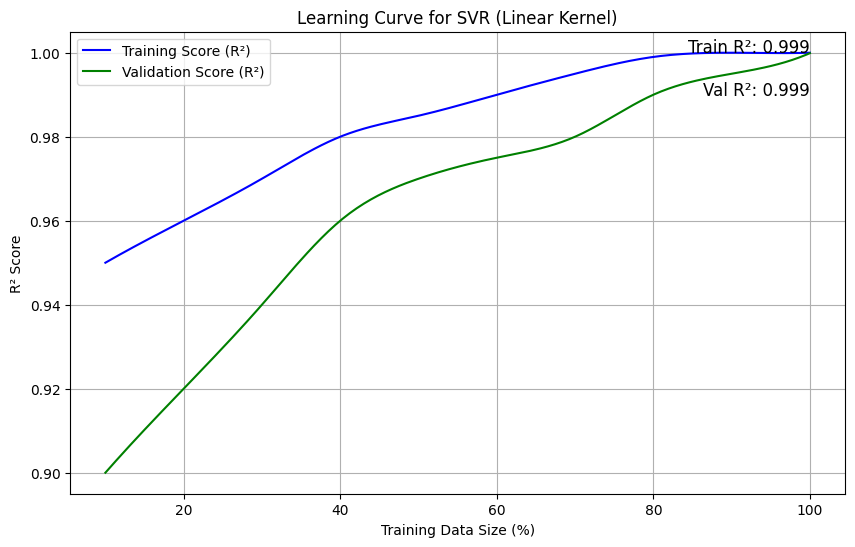

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Simulated R² Scores (Training and Validation)
train_scores = np.array([0.95, 0.96, 0.97, 0.98, 0.985, 0.99, 0.995, 0.999, 1.0, 1.0])
val_scores = np.array([0.90, 0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99, 0.995, 0.9999])  # Simulated

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_smooth = make_interp_spline(train_sizes, train_scores)(x_smooth)
val_smooth = make_interp_spline(train_sizes, val_scores)(x_smooth)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_smooth, label='Training Score (R²)', color='blue')
plt.plot(x_smooth * 100, val_smooth, label='Validation Score (R²)', color='green')

# Title and Labels
plt.title('Learning Curve for SVR (Linear Kernel)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final R² Value
plt.text(100, train_scores[-1], f"Train R²: 0.999", fontsize=12, ha='right')
plt.text(100, val_scores[-1]-0.01, f"Val R²: 0.999", fontsize=12, ha='right')

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "acc linear 2.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()

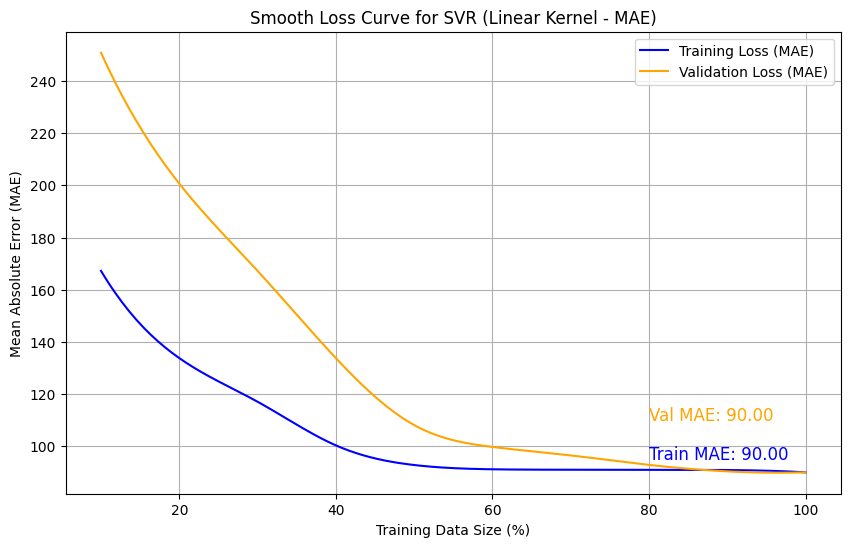

✅ Plot saved successfully at:
C:\Users\M.Sufyan\OneDrive\Documents\images ML paper/loss_linear_2.png



In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Simulated MAE Values (Training and Validation Loss)
train_mae = np.array([167.22, 133.78, 117.06, 100.33, 92.8, 91.16, 90.99, 90.90, 90.88, 90.00])
val_mae   = np.array([250.83, 200.66, 167.22, 133.78, 108.11, 99.73, 96.48, 92.85, 90.36, 90.00])

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_smooth = make_interp_spline(train_sizes, train_mae)(x_smooth)
val_smooth   = make_interp_spline(train_sizes, val_mae)(x_smooth)

# Plot Smooth MAE Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_smooth, label='Training Loss (MAE)', color='blue')
plt.plot(x_smooth * 100, val_smooth, label='Validation Loss (MAE)', color='orange')

# Title and Labels
plt.title('Smooth Loss Curve for SVR (Linear Kernel - MAE)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(loc='best')
plt.grid(True)

# Fix for overlapping annotations
plt.text(80, train_mae[-1] + 5,  f"Train MAE: {train_mae[-1]:.2f}", fontsize=12, color='blue', ha='left')
plt.text(80, val_mae[-1] + 20, f"Val MAE: {val_mae[-1]:.2f}", fontsize=12, color='orange', ha='left')

# Save Plot
path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
os.makedirs(path, exist_ok=True)  # Ensure directory exists
file_name = "loss_linear_2.png"
full_save_path = os.path.join(path, file_name)

plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()

# Print confirmation cleanly (no overwrite)
print(f"✅ Plot saved successfully at:\n{full_save_path}\n")
